# Model vs harness gaps

YAML wrapper for `configs/analysis/campaign_openai_model_harness_gaps.yaml`.

Read the report in this order:

1. **Overall** J and LoCoMo F1 — 4o-mini vs 4o-mini + Codex on full context, session summaries, and graph. Category 5 is dropped here.
2. **Category J bars** — same pair, full context, then session summaries. All five LoCoMo categories stay.
3. **2026 model vs 2024 model vs 2024 model + harness** — full-context J by category.
4. **Adversarial only** — the same three stacks on full context. Mem0 J is not scored here (the stored score is the skip placeholder 0). The bar is the LoCoMo refusal score: 1 when the answer says "not mentioned" or "no information available".
5. **Gap tables** — `delta` is left minus right, largest absolute gap first.

Traces for the harness full-context cell: `experiments/locomo-openai-codex-poc-readers/collected/runs/<run_id>/agent/trajectory.jsonl`. Start with the category that has the largest gap.


In [3]:
from pathlib import Path
import sys

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.memorybench.analysis import (
    load_campaign_yaml,
    notebook_posttest,
    notebook_pretest,
    run_report,
)

YAML = ROOT / "configs/analysis/campaign_openai_model_harness_gaps.yaml"
camp = load_campaign_yaml(YAML)
notebook_pretest(camp, root=ROOT)


## Pre-test — Model vs harness gaps (4o-mini, Codex, 2026)

Three charts. (1) Full-context J by LoCoMo category: GPT-4o-mini Chat Completions vs persist-off Codex workspace (same mini backbone). (2) Session-summary writer J by category: mini Chat Completions writer vs Codex writer, frozen mini reader. (3) Full-context J by category: 2026 Terra model-only vs 2024 mini model-only vs 2024 mini + Codex. Overall tables drop adversarial category 5. Category charts keep it. Mem0 J is not scored on category 5 (stored judge_score is the skip placeholder 0). The adversarial plot uses LoCoMo refusal: 1 when the answer says "not mentioned" or "no information available". delta in the gap tables is left minus right. Native Codex is audit-only unless comparison_status is comparable. Traces for the harness full-context cell live under experiments/locomo-openai-codex-poc-readers/collected/runs/.

Config: `C:/home/research/Distillation/distillation/configs/analysis/campaign_openai_model_harness_gaps.yaml`

### `readers` — `locomo-openai-codex-poc-readers`
- **not a scientific claim**
- expected cells: **3**
- hypothesis: Stuffed full_context is 4o-mini model-only.
- hypothesis: Persist-off workspace_files is 4o-mini + Codex.
- hypothesis: Persist-on workspace is excluded.

### `chat` — `locomo-openai-mini-writers-structured`
- **not a scientific claim**
- expected cells: **2**
- hypothesis: teacher_session_summaries is the 4o-mini writer.
- hypothesis: Frozen mini reader; the harness is the writer.

### `codex` — `locomo-openai-codex-poc-writers`
- **not a scientific claim**
- expected cells: **3**
- hypothesis: Codex teacher_session_summaries is the harness writer twin.
- hypothesis: Facts and graph stay out of the summary category chart.

### `year_2026` — `locomo-2026-readers-openai-deepseek`
- **not a scientific claim**
- expected cells: **8**
- hypothesis: GPT-5.6 Terra full_context thinking-off is the 2026 model bar.
- hypothesis: DeepSeek and thinking-on cells stay out of gap_stack.


_No `cost:` block in this campaign YAML._

C:\home\research\Distillation\distillation\src\memorybench\analysis\report.py:336: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(aligned, ignore_index=True)


Output `C:/home/research/Distillation/distillation/experiments/_campaign/openai_model_harness_gaps/analysis`

### Overall J and F1 — 4o-mini vs 4o-mini + Codex

memory_lane,mini_side,n,judge_score,locomo_f1,exact_match,answer_n_words
full_context,4o-mini,1540,0.7435,0.5364,0.213,4.0916
teacher_session_summaries,4o-mini,1540,0.6922,0.4727,0.1799,4.1032
teacher_graph,4o-mini,1540,0.361,0.2632,0.1182,3.6474
full_context,4o-mini + Codex,1540,0.6727,0.2426,0.0104,17.5123
teacher_session_summaries,4o-mini + Codex,1540,0.5662,0.4062,0.1506,3.8987
teacher_graph,4o-mini + Codex,1540,0.261,0.1869,0.0799,3.6591


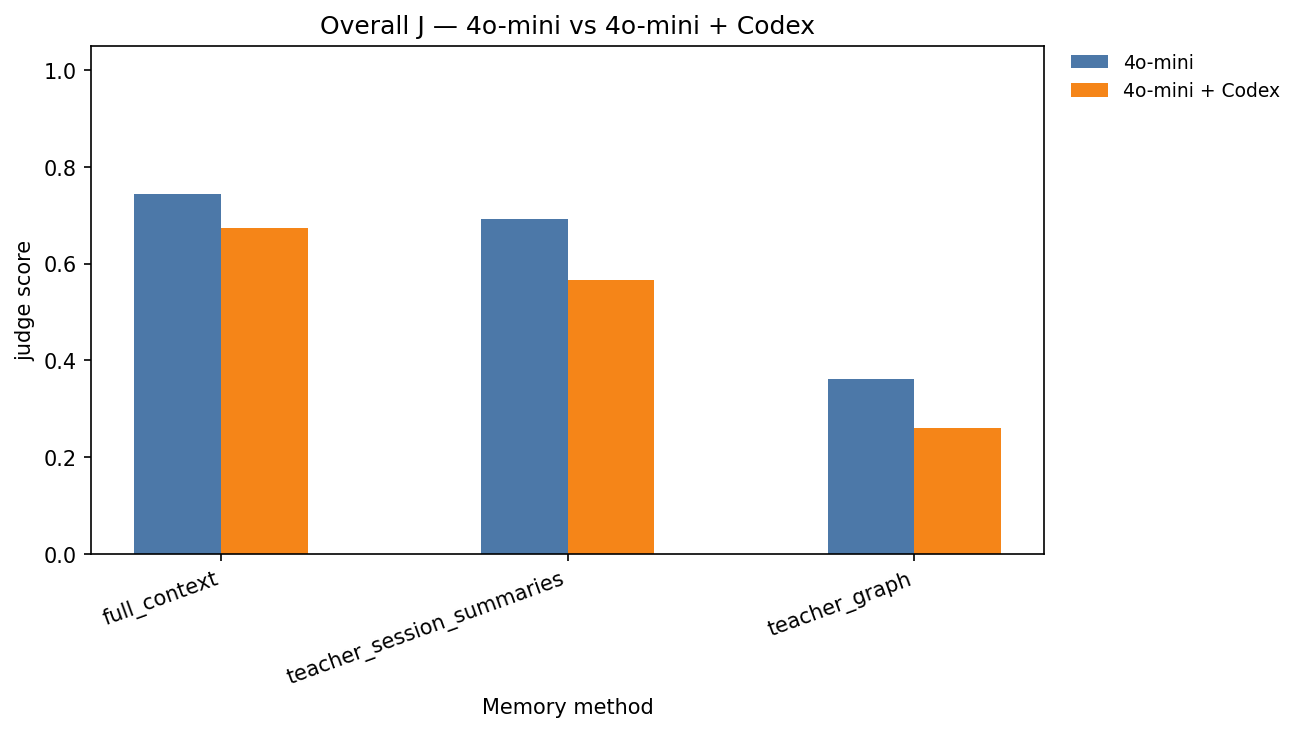

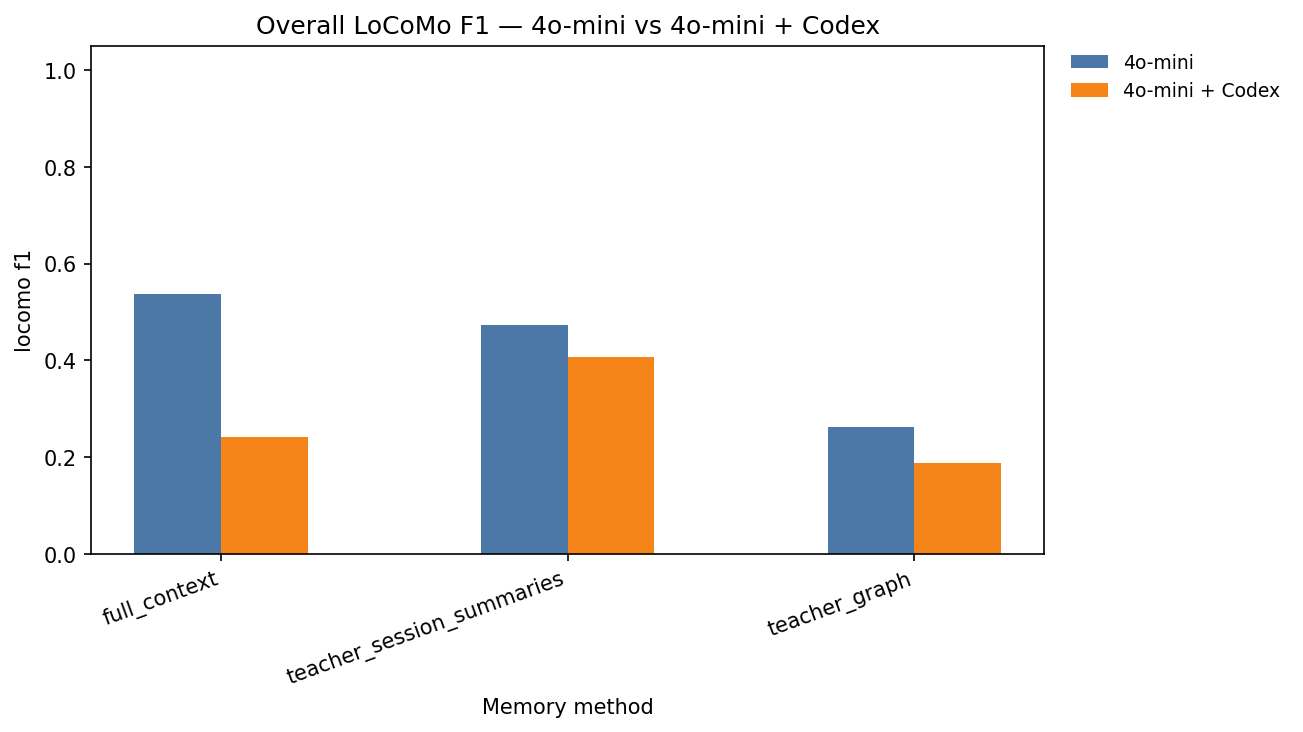

### Full-context J by category — 4o-mini vs 4o-mini + Codex

question_category,mini_side,n,judge_score
1 multi-hop,4o-mini,282,0.6383
2 temporal,4o-mini,321,0.5639
3 open-domain,4o-mini,96,0.4896
4 single-hop,4o-mini,841,0.8763
5 adversarial,4o-mini,446,0
1 multi-hop,4o-mini + Codex,282,0.6312
2 temporal,4o-mini + Codex,321,0.5078
3 open-domain,4o-mini + Codex,96,0.5104
4 single-hop,4o-mini + Codex,841,0.7681
5 adversarial,4o-mini + Codex,446,0


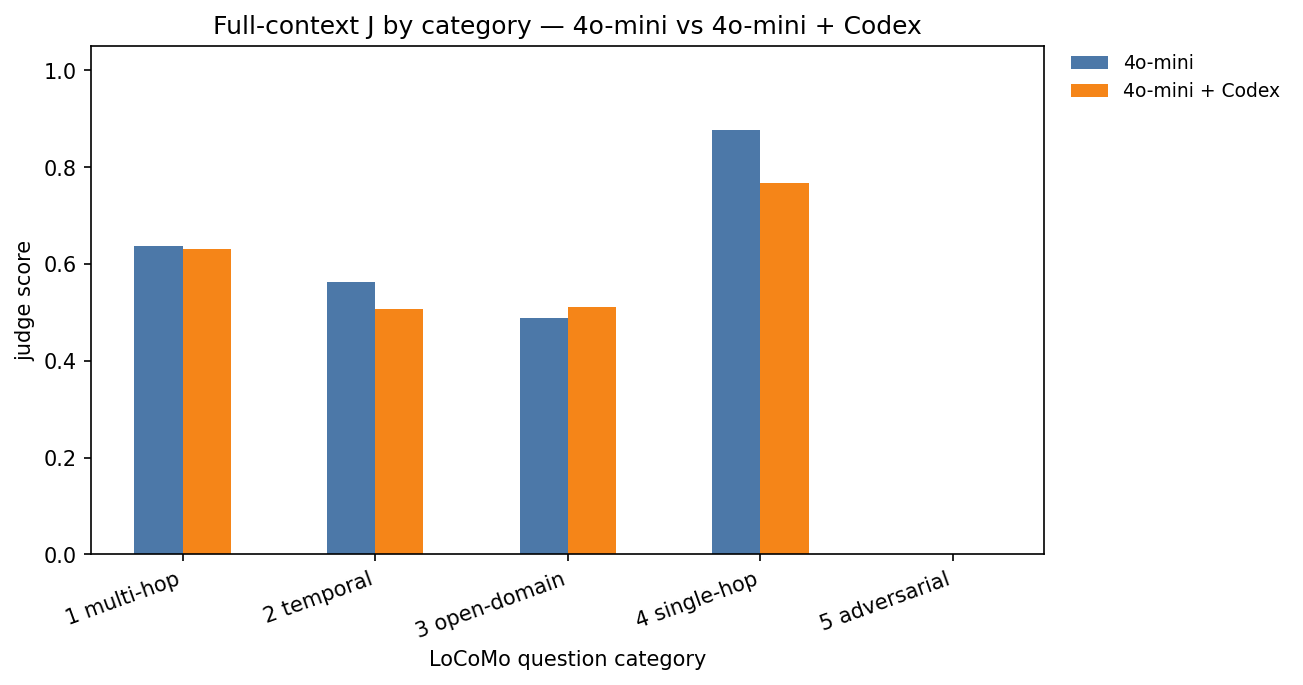

### Session-summary J by category — 4o-mini vs 4o-mini + Codex

question_category,mini_side,n,judge_score
1 multi-hop,4o-mini,282,0.6206
2 temporal,4o-mini,321,0.6604
3 open-domain,4o-mini,96,0.4375
4 single-hop,4o-mini,841,0.7574
5 adversarial,4o-mini,446,0
1 multi-hop,4o-mini + Codex,282,0.5603
2 temporal,4o-mini + Codex,321,0.4798
3 open-domain,4o-mini + Codex,96,0.3542
4 single-hop,4o-mini + Codex,841,0.6254
5 adversarial,4o-mini + Codex,446,0


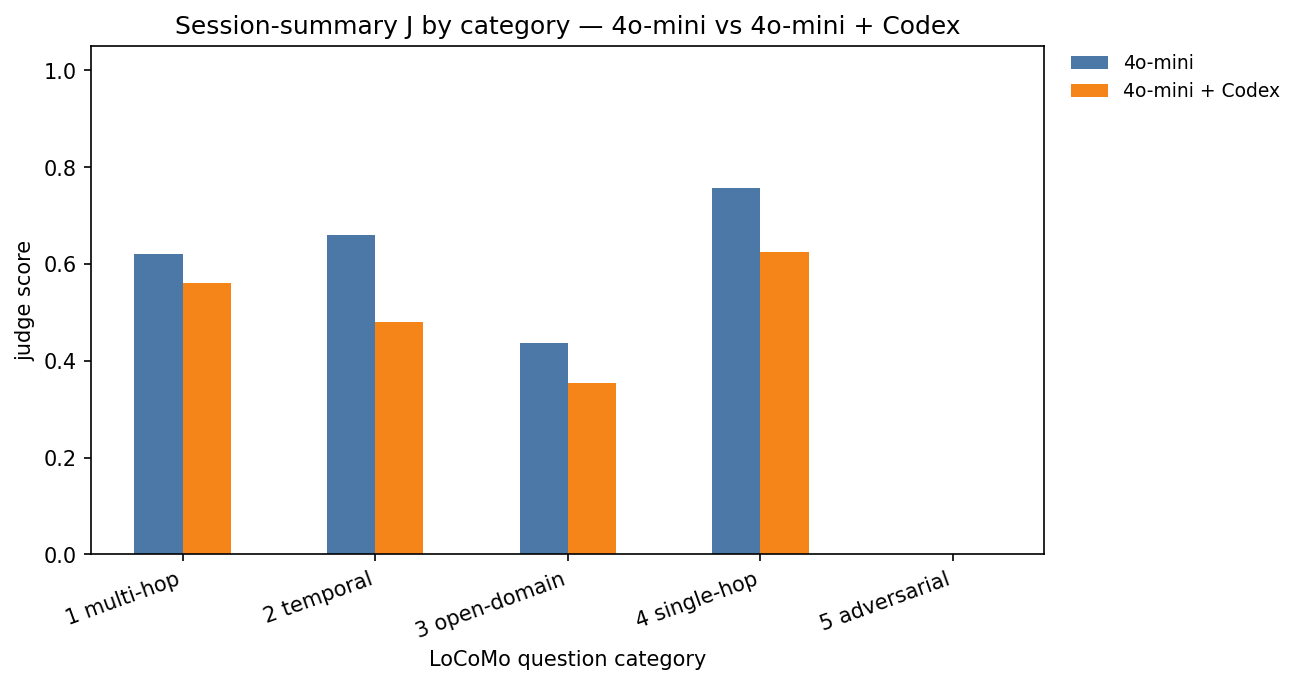

### Full-context overall — 2026 model vs 2024 model vs 2024 harness

gap_stack,n,judge_score,locomo_f1
2024 model,1540,0.7435,0.5364
2024 model + harness,1540,0.6727,0.2426
2026 model,1540,0.8753,0.6205


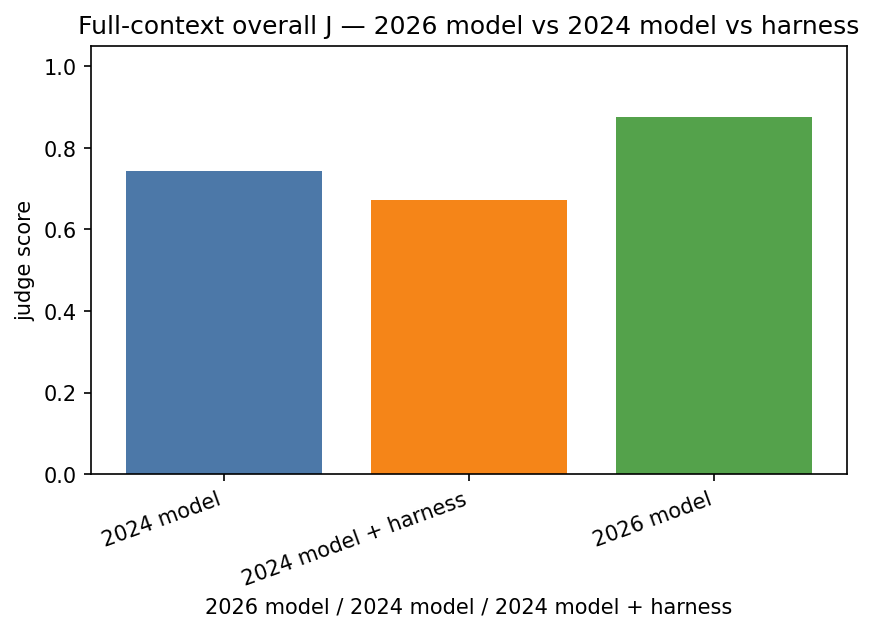

### Full-context J by category — 2026 model vs 2024 model vs 2024 harness

question_category,gap_stack,n,judge_score
1 multi-hop,2024 model,282,0.6383
2 temporal,2024 model,321,0.5639
3 open-domain,2024 model,96,0.4896
4 single-hop,2024 model,841,0.8763
5 adversarial,2024 model,446,0
1 multi-hop,2024 model + harness,282,0.6312
2 temporal,2024 model + harness,321,0.5078
3 open-domain,2024 model + harness,96,0.5104
4 single-hop,2024 model + harness,841,0.7681
5 adversarial,2024 model + harness,446,0


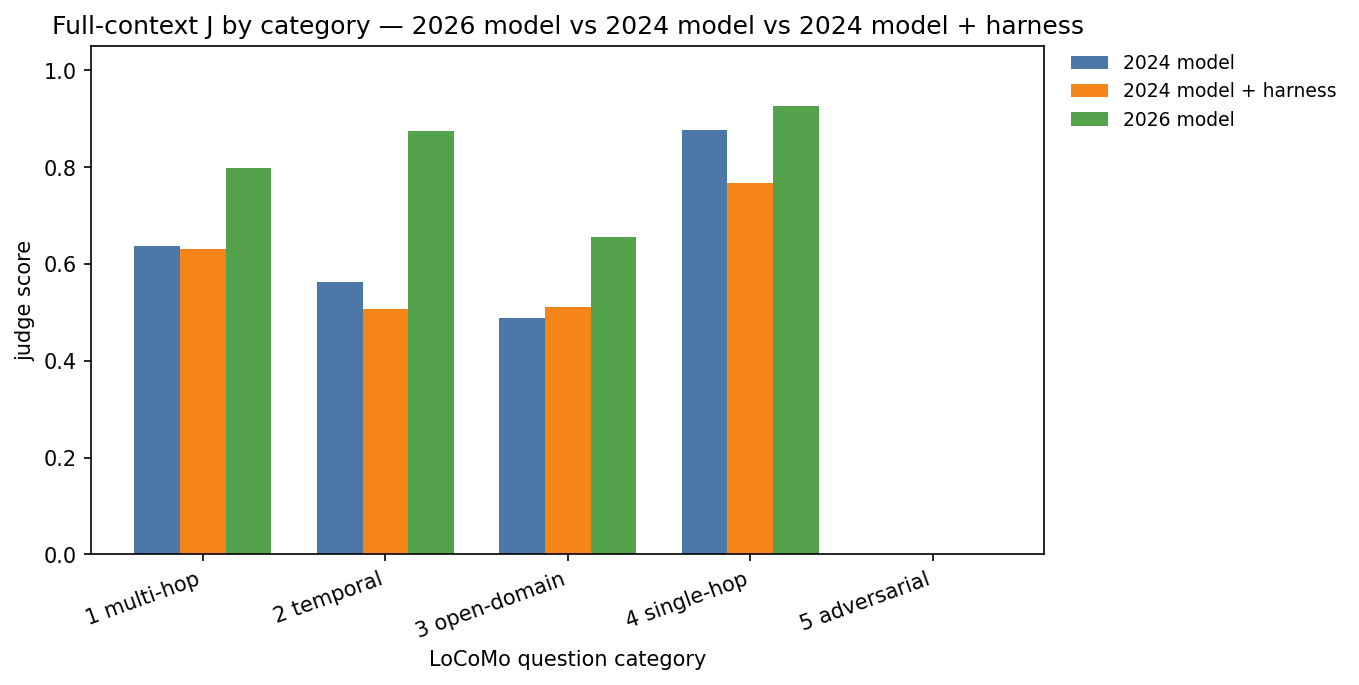

### Full-context adversarial refusal — 2026 model vs 2024 model vs 2024 + Codex

gap_stack,n,locomo_f1,judge_score
2024 model,446,0.0202,0
2024 model + harness,446,0.0291,0
2026 model,446,0.0269,0


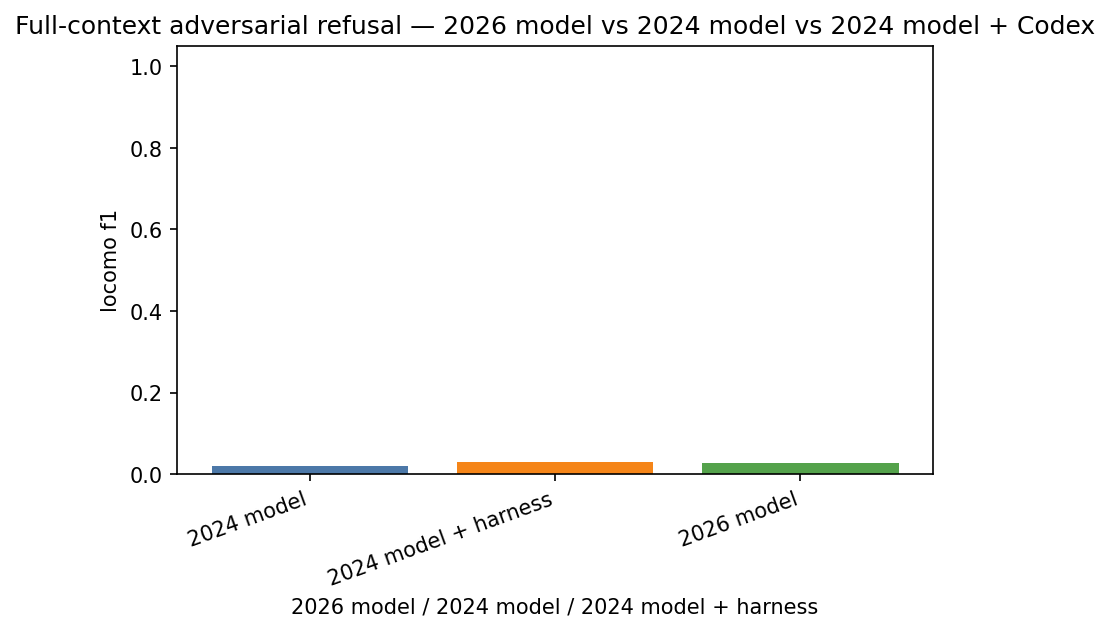

### Full-context category J gaps (4o-mini minus 4o-mini + Codex)

question_category,left_value,right_value,delta,left_label,right_label,metric
4 single-hop,0.8763,0.7681,0.1082,4o-mini,4o-mini + Codex,judge_score
2 temporal,0.5639,0.5078,0.0561,4o-mini,4o-mini + Codex,judge_score
3 open-domain,0.4896,0.5104,-0.0208,4o-mini,4o-mini + Codex,judge_score
1 multi-hop,0.6383,0.6312,0.0071,4o-mini,4o-mini + Codex,judge_score
5 adversarial,0,0,0,4o-mini,4o-mini + Codex,judge_score


### Session-summary category J gaps (4o-mini minus 4o-mini + Codex)

question_category,left_value,right_value,delta,left_label,right_label,metric
2 temporal,0.6604,0.4798,0.1807,4o-mini,4o-mini + Codex,judge_score
4 single-hop,0.7574,0.6254,0.132,4o-mini,4o-mini + Codex,judge_score
3 open-domain,0.4375,0.3542,0.0833,4o-mini,4o-mini + Codex,judge_score
1 multi-hop,0.6206,0.5603,0.0603,4o-mini,4o-mini + Codex,judge_score
5 adversarial,0,0,0,4o-mini,4o-mini + Codex,judge_score


### Full-context category J gaps (2026 model minus 2024 model)

...

question_category,left_value,right_value,delta,left_label,right_label,metric
4 single-hop,0.8763,0.7681,0.1082,2024 model,2024 model + harness,judge_score
2 temporal,0.5639,0.5078,0.0561,2024 model,2024 model + harness,judge_score
3 open-domain,0.4896,0.5104,-0.0208,2024 model,2024 model + harness,judge_score
1 multi-hop,0.6383,0.6312,0.0071,2024 model,2024 model + harness,judge_score
5 adversarial,0,0,0,2024 model,2024 model + harness,judge_score


### Post-test

check,result,detail
readers.scientific_claim,SKIP,declared not a scientific claim (smoke / subset)
readers.n_cells,PASS,"expected 3, actual 3"
chat.scientific_claim,SKIP,declared not a scientific claim (smoke / subset)
chat.n_cells,PASS,"expected 2, actual 2"
codex.scientific_claim,SKIP,declared not a scientific claim (smoke / subset)
codex.n_cells,PASS,"expected 3, actual 3"
year_2026.scientific_claim,SKIP,declared not a scientific claim (smoke / subset)
year_2026.n_cells,PASS,"expected 8, actual 8"


Post-test: declared expectations matched the pack where data exists.

,check,result,detail
0,readers.scientific_claim,SKIP,declared not a scientific claim (smoke / subset)
1,readers.n_cells,PASS,"expected 3, actual 3"
2,chat.scientific_claim,SKIP,declared not a scientific claim (smoke / subset)
3,chat.n_cells,PASS,"expected 2, actual 2"
4,codex.scientific_claim,SKIP,declared not a scientific claim (smoke / subset)
5,codex.n_cells,PASS,"expected 3, actual 3"
6,year_2026.scientific_claim,SKIP,declared not a scientific claim (smoke / subset)
7,year_2026.n_cells,PASS,"expected 8, actual 8"


In [4]:
reports = run_report(YAML, root=ROOT)
notebook_posttest(camp, report=reports[-1], root=ROOT)
